# Demo nhóm 1 - RNN, LSTM: Phân loại Cảm xúc với Mạng LSTM & BiLSTM

## Thành viên:
- Bảo Quý Định Tân - 24520028
- Lê Văn Thức - 24521748
- Lê Phạm Thành Nhân - 24520022

## 1. Giới thiệu Bài toán
Trong kỷ nguyên dữ liệu lớn, việc tự động phân tích hàng triệu bình luận, đánh giá của người dùng là một nhu cầu thiết yếu. Dự án này giải quyết bài toán **Phân tích Cảm xúc (Sentiment Analysis)** – một ứng dụng kinh điển của bài toán **Phân loại Chuỗi (Sequence Classification)** trong Xử lý Ngôn ngữ Tự nhiên (NLP).

**Mục tiêu:** Xây dựng một mô hình Deep Learning có khả năng đọc một đoạn văn bản (review phim) và dự đoán xem người viết đang mang trạng thái cảm xúc **Tích cực (Positive - 1)** hay **Tiêu cực (Negative - 0)**.

**Tập dữ liệu:** Tập dữ liệu **IMDB Movie Reviews**, gồm hàng chục nghìn bài đánh giá phim đã được gán nhãn sẵn.

## 2. Nền tảng Lý thuyết (Ứng dụng Chương 13)
Notebook này được xây dựng nhằm mô phỏng và kiểm chứng các khái niệm lý thuyết cốt lõi:
* **Word Embeddings:** Biến đổi ngôn ngữ tự nhiên thành các vector toán học không gian nhiều chiều.
* **Mạng LSTM (Long Short-Term Memory):** Sử dụng cơ chế các "cổng" (gates) để khắc phục hiện tượng triệt tiêu đạo hàm (vanishing gradient) của RNN truyền thống, giúp mô hình duy trì bộ nhớ dài hạn đối với các câu văn dài.
* **Bidirectional LSTM (BiLSTM):** Mở rộng kiến trúc bằng cách quét chuỗi văn bản theo cả hai chiều (từ trái sang phải và từ phải sang trái). Việc nối hai trạng thái ẩn (forward và backward) giúp mô hình nắm bắt trọn vẹn ngữ cảnh của một từ dựa vào cả các từ đứng trước và đứng sau nó.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

# 1. Cài đặt các siêu tham số
VOCAB_SIZE = 10000  # Kích thước từ vựng (chỉ lấy 10,000 từ phổ biến nhất)
MAX_LEN = 200       # Giới hạn độ dài của mỗi chuỗi (bài đánh giá)
EMBEDDING_DIM = 128 # Kích thước vector nhúng
HIDDEN_DIM = 128    # Số lượng đơn vị ẩn trong LSTM
BATCH_SIZE = 128
EPOCHS = 15         # Giữ ở mức nhỏ để demo chạy nhanh

print("Đang tải dữ liệu IMDB...")
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# 2. Tiền xử lý dữ liệu (Padding)
# Các chuỗi ngôn ngữ có độ dài khác nhau, ta cần chuẩn hóa chúng về cùng một kích thước
X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

I0000 00:00:1777912247.553489  224969 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777912247.612528  224969 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777912248.769769  224969 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Đang tải dữ liệu IMDB...
Kích thước tập huấn luyện: (25000, 200)
Kích thước tập kiểm tra: (25000, 200)


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional

def build_sentiment_classifier(vocab_size, max_len, embed_dim, hidden_dim, is_bidirectional=False):
    model = Sequential()
    
    # Lớp nhúng biến các từ thành vector
    model.add(Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len))
    
    if is_bidirectional:
        # LSTM Hai chiều: Kết hợp ngữ cảnh từ trái sang phải và phải sang trái
        model.add(Bidirectional(LSTM(hidden_dim, dropout=0.2, recurrent_dropout=0.2)))
    else:
        # LSTM Đơn hướng: Chỉ sử dụng ngữ cảnh phía trước (left context)
        model.add(LSTM(hidden_dim, dropout=0.2, recurrent_dropout=0.2))
        
    # Lớp phân loại cuối cùng
    model.add(Dense(1, activation='sigmoid'))
    
    # Biên dịch mô hình với cross-entropy loss cho bài toán phân loại nhị phân
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    return model

=== 1. KHỞI TẠO VÀ HUẤN LUYỆN: STANDARD LSTM ===
Epoch 1/15


/home/jupyter-iec2024iot06/.conda/envs/asamai-uit/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1777912252.432058  224969 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
E0000 00:00:1777912252.455003  224969 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777912252.474579  224969 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform

157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 195ms/step - accuracy: 0.7613 - loss: 0.5030 - val_accuracy: 0.8306 - val_loss: 0.3903
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - accuracy: 0.8597 - loss: 0.3414 - val_accuracy: 0.8528 - val_loss: 0.3596
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - accuracy: 0.8845 - loss: 0.2883 - val_accuracy: 0.8144 - val_loss: 0.4118
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.9032 - loss: 0.2501 - val_accuracy: 0.8204 - val_loss: 0.4031

=== 2. KHỞI TẠO VÀ HUẤN LUYỆN: BIDIRECTIONAL LSTM ===
Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 336ms/step - accuracy: 0.7452 - loss: 0.5105 - val_accuracy: 0.7654 - val_loss: 0.4905
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 333ms/step - accuracy: 0.8604 - loss: 0.3362 - val_accuracy: 0.8584 - val_loss: 0.3516
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 331ms/step - accuracy: 0.8923 - loss: 0.2705 - val_accuracy: 0.8674 - val_loss: 0.3300
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━

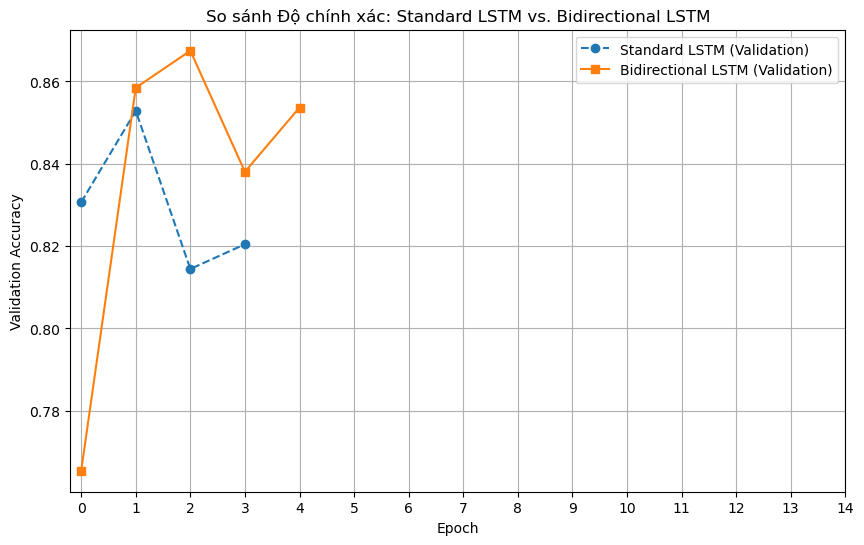

In [3]:
from tensorflow.keras.callbacks import EarlyStopping

# Khởi tạo callback dừng sớm
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Khởi tạo mô hình
print("=== 1. KHỞI TẠO VÀ HUẤN LUYỆN: STANDARD LSTM ===")
model_lstm = build_sentiment_classifier(VOCAB_SIZE, MAX_LEN, EMBEDDING_DIM, HIDDEN_DIM, False)
history_lstm = model_lstm.fit(
    X_train, y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n=== 2. KHỞI TẠO VÀ HUẤN LUYỆN: BIDIRECTIONAL LSTM ===")
model_bilstm = build_sentiment_classifier(VOCAB_SIZE, MAX_LEN, EMBEDDING_DIM, HIDDEN_DIM, True)
history_bilstm = model_bilstm.fit(
    X_train, y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Đánh giá trên tập Test ẩn (Chưa từng nhìn thấy trong quá trình train)
print("\n=== 3. ĐÁNH GIÁ TRÊN TẬP TEST ===")
_, acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
_, acc_bilstm = model_bilstm.evaluate(X_test, y_test, verbose=0)

print(f"Độ chính xác của Standard LSTM     : {acc_lstm * 100:.2f}%")
print(f"Độ chính xác của Bidirectional LSTM: {acc_bilstm * 100:.2f}%")

# Vẽ biểu đồ so sánh độ chính xác trên tập Validation
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['val_accuracy'], label='Standard LSTM (Validation)', marker='o', linestyle='dashed')
plt.plot(history_bilstm.history['val_accuracy'], label='Bidirectional LSTM (Validation)', marker='s')
plt.title('So sánh Độ chính xác: Standard LSTM vs. Bidirectional LSTM')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.xticks(range(EPOCHS))
plt.legend()
plt.grid(True)
plt.show()

## Nhận xét

Dựa vào quá trình huấn luyện và biểu đồ so sánh phía trên, chúng ta có thể đối chiếu thực tế với các lý thuyết cốt lõi trong **Chương 13** và rút ra một số kết luận sau:

### 1. So sánh hiệu năng thực tế
* **Về Độ chính xác (Accuracy):** Mô hình **Bidirectional LSTM** thường cho kết quả chính xác hơn và có xu hướng hội tụ nhanh hơn qua từng epoch so với LSTM đơn hướng.
* **Về Chi phí tính toán:** Thời gian huấn luyện mỗi epoch của BiLSTM lâu hơn đáng kể (thường là gấp đôi) so với Standard LSTM. Đây là sự đánh đổi kinh điển trong Deep Learning: dùng thêm tài nguyên tính toán để đổi lấy hiệu năng phân loại cao hơn.

### 2. Lý giải dưới góc độ lý thuyết
* **Standard LSTM (Đơn hướng):** Chỉ xử lý văn bản theo một chiều thời gian (từ trái sang phải). Tại bước thời gian $t$, nó chỉ biết được các từ trong quá khứ (left context).
* **Bidirectional LSTM (Hai chiều):** Trong ngôn ngữ tự nhiên, ý nghĩa của một từ thường phụ thuộc rất nhiều vào các từ đứng *sau* nó. Bằng cách nối (concatenate) đầu ra của hai mạng LSTM chạy ngược chiều nhau, biểu diễn tại mỗi bước thời gian giờ đây chứa cả thông tin từ đầu câu đến cuối câu. 
> *Ví dụ:* Trong câu "Phim này **không** hay như tôi nghĩ", từ "không" nằm ở đầu câu mang tính quyết định cảm xúc. Quá trình backward của BiLSTM (quét từ cuối lên đầu) sẽ truyền thông tin ngữ cảnh ngược lại, giúp mô hình nắm bắt cấu trúc phủ định này chặt chẽ hơn.